In [1]:
import os
import tqdm
import numpy as np
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from timm import create_model
import random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.utils.data import WeightedRandomSampler

/home/sara/distilaimedical/distilvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)

device =  cuda


In [4]:
class DDR_Dataset(Dataset):
    def __init__(self, root, mode, transform=None, small=True):
        if small:
            dir_name = mode + "512"
        else:
            dir_name = mode
        self.img_dir = os.path.join(root, dir_name)
        self.transform = transform
        self.data = []

        labels_file = mode + ".txt"
        path = os.path.join(root, labels_file)
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                img_name, grade = line.split()
                self.data.append((img_name, int(grade)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        t0 = time.time()
        img_name, label = self.data[index]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        t1 = time.time()

        if self.transform:
            img = self.transform(img)
        t2 = time.time()
        
        return img, label

In [5]:
img_size = 224
root = "./ddr/DDR-dataset/DR_grading"

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

def get_mean_std():
    norm_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

    norm_dataset = DDR_Dataset(root=root, mode='train', transform=norm_transform, small=True)
    norm_loader = DataLoader(norm_dataset, batch_size=64, shuffle=False, num_workers=8)

    count_all_pixels = 0
    mean = torch.zeros(3)
    std = torch.zeros(3)

    for images, _ in norm_loader:
        pixels_in_batch = len(images) * (img_size ** 2)
        mean += images.sum(dim=[0, 2, 3])
        std += (images ** 2).sum(dim=[0, 2, 3])
        count_all_pixels += pixels_in_batch

    mean = mean / count_all_pixels
    std = torch.sqrt(std / count_all_pixels - mean ** 2)
    print(f"Mean: {mean}")
    print(f"Std: {std}")
    return mean, std

In [7]:
# 512
# mean = (0.4139, 0.2574, 0.1288)
# std = (0.2952, 0.2055, 0.1408)

# 256
# mean = (0.4143, 0.2579, 0.1292)
# std = (0.2947, 0.2049, 0.1402)

# 224
mean = (0.4140, 0.2575, 0.1289)
std = (0.2945, 0.2047, 0.1401)

if mean == None:
	mean, std = get_mean_std()

transform_train = transforms.Compose([
    #CropBackground(threshold=5),
    transforms.Resize((img_size, img_size)),
	transforms.RandomAffine(
		# translation,
        translate=(0.1, 0.1),
		# stretching,
		scale=(0.9, 1.1), 
		# rotation,
        degrees=15,
		
		fill=0
    ),
	# flipping, 
    transforms.RandomHorizontalFlip(),
	# and colour augmentation
    transforms.ColorJitter(brightness=0.5, contrast=1, saturation=0.1, hue=0.5),

    transforms.ToTensor(),
	transforms.Normalize(mean, std)
])

transform_eval = transforms.Compose([
	#CropBackground(threshold=5),
	transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
	transforms.Normalize(mean, std)
])

In [8]:
trainset = DDR_Dataset(root, "train", transform=transform_train)
valset = DDR_Dataset(root, "valid", transform=transform_eval)
testset = DDR_Dataset(root, "test", transform=transform_eval)

In [9]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [10]:
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [11]:
from sklearn.metrics import cohen_kappa_score
def evaluate(model, loader, criterion, confusion_matrix_show=False):
	model.eval()
	total_loss, correct = 0, 0
	correct_per_class = np.zeros(6)
	class_nums = np.zeros(6)
	all_labels = []
	all_preds = []
	with torch.no_grad():
		for images, labels in loader:
			images = images.to(device, non_blocking=True)
			labels = labels.to(device, non_blocking=True)
			outputs = model(images)
			total_loss += criterion(outputs, labels).item()
			preds = outputs.argmax(1)

			labels_np = labels.cpu().numpy()
			preds_np = preds.cpu().numpy()

			class_nums += np.bincount(labels_np, minlength=6)
			
			correct_mask = (preds_np == labels_np)
			correct_per_class += np.bincount(labels_np[correct_mask], minlength=6)
			correct += (outputs.argmax(1) == labels).sum().item()

			all_labels.append(labels_np)
			all_preds.append(preds_np)

		all_labels = np.concatenate(all_labels)
		all_preds = np.concatenate(all_preds) 
		
		per_class_acc = np.divide(
			correct_per_class, class_nums,
			out=np.zeros_like(correct_per_class), where=class_nums != 0
			)

		kappa = cohen_kappa_score(all_preds, all_labels)
		
		if confusion_matrix_show:
			cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5])
			disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4, 5])
			disp.plot(cmap='Blues', values_format='d')
			plt.title("Confusion Matrix")
			plt.show()
		return total_loss / len(loader), correct / len(loader.dataset), per_class_acc, kappa


In [12]:
def get_dataloaders(seed=42):
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=4, worker_init_fn=seed_worker, generator=g, pin_memory=True)
    valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    return trainloader,valloader, testloader

In [13]:
def get_resampled_dataloaders(seed=42):
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    labels_cpu = np.array([label for _, label in trainset.data])
    class_counts = np.bincount(labels_cpu, minlength=6)
    class_weights = 1/class_counts
    sample_weights = [class_weights[i] for i in labels_cpu]
    
    sampler= WeightedRandomSampler(weights=sample_weights, num_samples=len(labels_cpu), replacement=True)

    trainloader = DataLoader(trainset, batch_size=64, sampler=sampler, num_workers=4, worker_init_fn=seed_worker, generator=g, pin_memory=True)
    valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
    return trainloader,valloader, testloader

In [19]:
def execution_loop(model, optimizer, epochs, training_function, lr_scheduler, dataloader_function=get_dataloaders, print_stats=True, **kwargs):
  trainloader, valloader, testloader = dataloader_function(42)
  criterion = nn.CrossEntropyLoss()
  scaler = torch.amp.GradScaler('cuda')
  if print_stats:
    print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
    print("-" * 52)
  for epoch in range(epochs):
      # current_lr = optimizer.param_groups[0]['lr']
      # print(current_lr)
      tr_loss, tr_acc = training_function(model, trainloader, optimizer, criterion, scaler, **kwargs)
      vl_loss, vl_acc = validate(model, valloader, criterion)
      if print_stats:
        print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {vl_loss:>8.4f}  {vl_acc:>7.7f}")
      lr_scheduler.step()
  test_loss, overall_test_accuracy, test_acc_sep, kappa = evaluate(model, testloader, criterion, confusion_matrix_show=True)
  average_test_accuracy = np.sum(test_acc_sep) / 6
  print(f"\nTest metrics:  Loss {test_loss:>8.4f}  OA {overall_test_accuracy:.4f}  AA {average_test_accuracy:.4f}, kappa {kappa:>.4f}")
  for i in range(0, 6):
    print(f"{i}: {test_acc_sep[i]:>10.4f}")

In [ ]:
def see_distribution(trainloader):

	class_proportions = []
	for _, labels in trainloader:
		labels_cpu = labels.cpu().numpy()
		class_nums = np.bincount(labels_cpu, minlength=6)
		class_proportions.append(class_nums)

	data = np.array(class_proportions)
	num_batches, num_classes = data.shape
	batch_idx = np.arange(num_batches)

	fig, ax = plt.subplots(figsize=(10, 5))
	bottom = np.zeros(num_batches)
	for c in range(num_classes):
		ax.bar(batch_idx, data[:, c], bottom=bottom, label=f'Class {c}')
		bottom += data[:, c]

	ax.set_xlabel('Batch')
	ax.set_ylabel('Sample count')
	ax.set_title('Class distribution per batch')
	ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.tight_layout()
	plt.show()

		

trainloader, _, _ = get_dataloaders(42)
see_distribution(trainloader)
trainloader, _, _ = get_resampled_dataloaders(42)
see_distribution(trainloader)

In [16]:
def run_inference(model_name, num_epochs, start_lr, end_lr, dataloader):
	set_seed(42)
	model = create_model(model_name, pretrained=True, num_classes=6)
	model.to(device)
	optim = torch.optim.Adam(model.parameters(), lr=start_lr)
	scheduler = lr_scheduler.CosineAnnealingLR(optim, T_max=num_epochs, eta_min=end_lr)
	execution_loop(model, optim, num_epochs, train_epoch, scheduler, dataloader, print_stats=True)


In [17]:
# run_inference('convnext_tiny.fb_in22k', 7, 1e-5, 1e-9, get_dataloaders)
# run_inference('convnext_tiny.fb_in22k', 5, 1e-5, 1e-9, get_resampled_dataloaders)

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
    1      1.7123     0.2916    1.5158  0.5265276
    2      1.4968     0.4006    1.3098  0.4493231
    3      1.3395     0.4511    1.1717  0.4701793
    4      1.2458     0.4881    1.1254  0.5345774
    5      1.1691     0.5241    1.0806  0.5418954
    6      1.1077     0.5384    1.0845  0.5268935
    7      1.0837     0.5555    1.0675  0.5576290
    8      1.0562     0.5656    1.0174  0.5788511
    9      0.9973     0.5974    1.0452  0.5404318
   10      0.9844     0.6028    1.0307  0.5389682
   11      0.9517     0.6056    1.0025  0.5660446
   12      0.9194     0.6282    0.8585  0.6491035
   13      0.8988     0.6369    0.9396  0.5923893
   14      0.8982     0.6394    0.9320  0.5975119
   15      0.8684     0.6483    0.9209  0.6015368
   16      0.8551     0.6473    0.9165  0.5825101
   17      0.8407     0.6587    0.9467  0.5660446
   18      0.8100     0.6651    0.9034  0.5956824

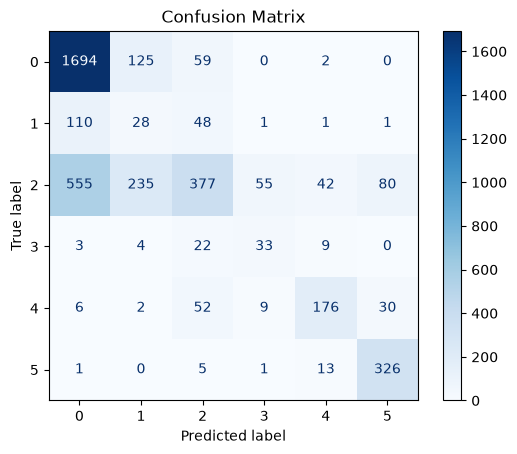


Test metrics:  Loss   0.9480  OA 0.6417  AA 0.5628, kappa 0.4676
0:     0.9011
1:     0.1481
2:     0.2805
3:     0.4648
4:     0.6400
5:     0.9422


In [20]:
# run_inference('resnet18', 5, 1e-3, 1e-5, get_dataloaders)
run_inference('resnet18', 80, 1e-4, 1e-7, get_resampled_dataloaders)